In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/india-air-quality-data/data.csv


In [22]:
import pandas as pd
import numpy as np
import math

df = pd.read_csv("/kaggle/input/india-air-quality-data/data.csv",encoding="latin1")   

/tmp/ipykernel_420/813923704.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/india-air-quality-data/data.csv",encoding="latin1")


In [23]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [24]:
#roll no-102317165
r = 102317165   
ar = 0.05 * (r % 7)
br = 0.3 * (r % 5 + 1)


In [25]:
x = df["no2"].dropna().values

In [26]:
x


array([17.4,  7. , 28.5, ..., 45. , 50. , 46. ])

In [27]:
t = br * x
t = np.clip(t, -1, 1)    
z = x + ar * np.arcsin(t)


In [28]:
print(z)

[17.8712389  7.4712389 28.9712389 ... 45.4712389 50.4712389 46.4712389]


****Maximum Likelihood Estimation (MLE) for Gaussian Distribution****


****p(z)=1/sqrt(2πσ2).exp(−(z−μ)2/(2σ2))****

In [29]:
mu = np.mean(z)
sigma2 = np.var(z)         

#calculate lambda and c params
lam = 1 / (2 * sigma2) #1/(2σ2)
c = 1 / np.sqrt(2 * math.pi * sigma2) #1/sqrt(2πσ2)

#REQUIRED ANSWERS 
print("mu =", mu ,"lambda =", lam,"c =", c)

mu = 26.279555037631454 lambda = 0.0014601535388470853 c = 0.02155878722844295



# Step-1:
NO2 values were transformed using nonlinear functionz = x + ar·arcsin(br·x). Since arcsin is defined only in [−1,1],br·x was clipped to this range before applying transformation.
#
# Step-2:
Parameters μ and σ² were estimated using sample mean and variance(Maximum Likelihood Estimation). Then λ and c were computed usingλ = 1/(2σ²) and c = 1/√(2πσ²).
#

# Visualization 

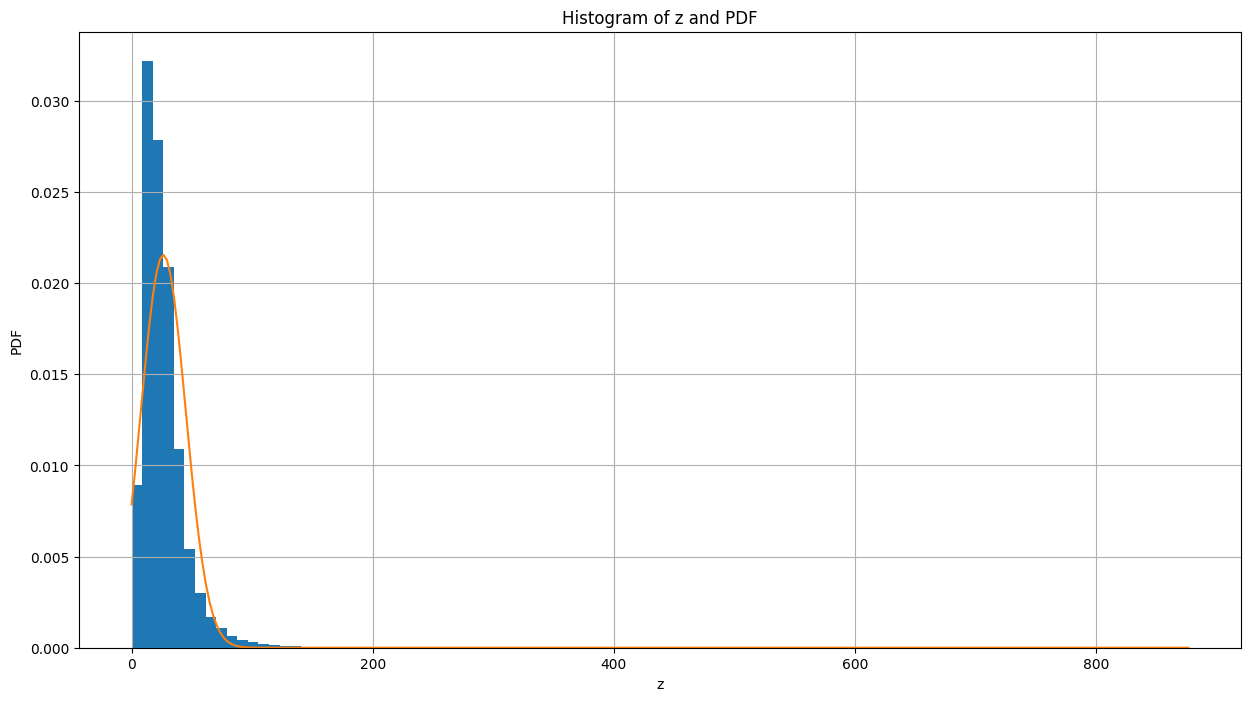

In [30]:
import matplotlib.pyplot as plt

z_min, z_max = z.min(), z.max()
z_vals = np.linspace(z_min, z_max, 300)

pdf_vals = c * np.exp(-lam * (z_vals - mu)**2)

plt.figure(figsize=(15,8))
plt.hist(z, bins=100, density=True)
plt.plot(z_vals, pdf_vals)
plt.xlabel("z")
plt.ylabel("PDF")
plt.title("Histogram of z and PDF")
plt.grid()
plt.show()
